In [2]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torchaudio
import soundfile as sf
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path        

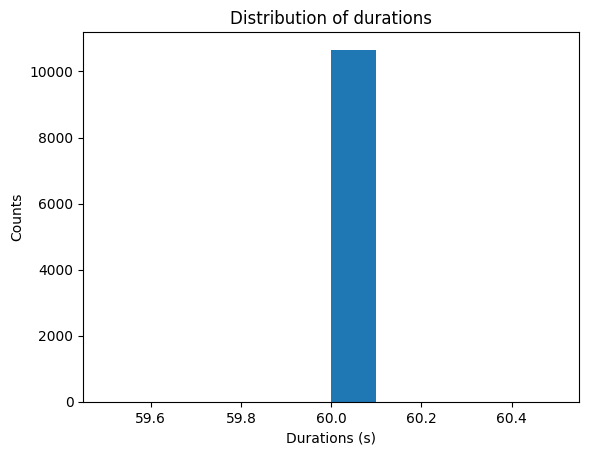

In [3]:
files = Path('../data/train_soundscapes').rglob('*.ogg')
durations = [sf.info(str(f)).duration for f in files]
plt.hist(durations, bins=10)
plt.title('Distribution of durations')
plt.xlabel('Durations (s)')
plt.ylabel('Counts')
plt.show()

In [10]:
train_sc_labels_df = pd.read_csv('../data/train_soundscapes_labels.csv')
train_sc_labels_df.head(3)

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380


In [9]:
taxonomy_df = pd.read_csv('../data/taxonomy.csv')
taxonomy_df.head(2)

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia


In [14]:
labels0 = train_sc_labels_df['primary_label'][0].split(';')

In [16]:
taxonomy_set = set(taxonomy_df['primary_label'])
contain_in_taxonomy = [ specy in taxonomy_set for specy in labels0]
print(contain_in_taxonomy)

[True, True, True, True, True]


In [18]:
labels_set = set(train_sc_labels_df['primary_label'].str.split(';').explode())
print(len(labels_set))

75


In [34]:
missing_in_labels_set = taxonomy_set - labels_set
missing_in_taxonomy_set = labels_set - taxonomy_set
print(len(missing_in_labels_set))
print(missing_in_taxonomy_set) 
label2idx = {label: idx for idx, label  in enumerate(sorted(taxonomy_set)) }
print(label2idx)

159
set()
{'1161364': 0, '116570': 1, '1176823': 2, '1491113': 3, '1595929': 4, '209233': 5, '22930': 6, '22956': 7, '22961': 8, '22967': 9, '22973': 10, '22983': 11, '22985': 12, '23150': 13, '23154': 14, '23158': 15, '23176': 16, '23724': 17, '24279': 18, '24285': 19, '24287': 20, '24321': 21, '244024': 22, '25073': 23, '25092': 24, '25214': 25, '326272': 26, '41970': 27, '43435': 28, '47144': 29, '47158son01': 30, '47158son02': 31, '47158son03': 32, '47158son04': 33, '47158son05': 34, '47158son06': 35, '47158son07': 36, '47158son08': 37, '47158son09': 38, '47158son10': 39, '47158son11': 40, '47158son12': 41, '47158son13': 42, '47158son14': 43, '47158son15': 44, '47158son16': 45, '47158son17': 46, '47158son18': 47, '47158son19': 48, '47158son20': 49, '47158son21': 50, '47158son22': 51, '47158son23': 52, '47158son24': 53, '47158son25': 54, '476521': 55, '516975': 56, '517063': 57, '555123': 58, '555145': 59, '555146': 60, '64898': 61, '65377': 62, '65380': 63, '66971': 64, '67107': 65

In [36]:
labels_series = train_sc_labels_df['primary_label'].str.split(';').explode()
labels_series = labels_series.map(label2idx)
labels_series.head(2)

0     8
0    15
Name: primary_label, dtype: int64

In [38]:
labels_series.unique()

array([  8,  15,  21,  57,  63,  10,  94,  29,  60,  64,  18,   3,   9,
       214,  66,  44,  45,  46,  54,   1,  97,  62,  26,  36, 100, 215,
       225, 136, 141, 180, 160,  32,  47,  48, 123, 211,  56, 158, 139,
        37,  40,  49,  42,  51,  52,  50,  39,  34, 165,  24,  93, 148,
       103, 104, 144,  69, 206,  30,  41,  53,  38,  33,  74,  35, 219,
        23,  65, 190, 132, 115, 179, 174,  28,  31,  43])

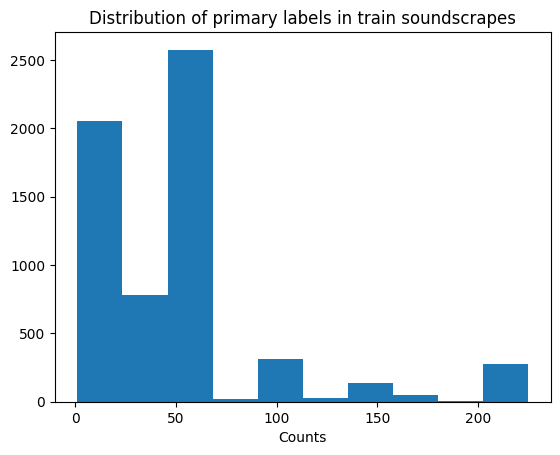

In [37]:

# labels_lst = list(.map(label2idx))
plt.hist(labels_series)
plt.title('Distribution of primary labels in train soundscrapes')
plt.xlabel('Labels')
plt.xlabel('Counts')
plt.show()

In [40]:
train_df = pd.read_csv('../data/train.csv')
train_label_set = set(train_df['primary_label'].unique())
len(train_label_set)

206

In [45]:
in_sc_not_in_train_set = labels_set - train_label_set
print(in_sc_not_in_train_set)
print(len(in_sc_not_in_train_set))
print(len(train_label_set))
print(len(labels_set))
print(len(taxonomy_set))

{'25073', '47158son22', '47158son15', '47158son18', '47158son17', '47158son23', '47158son04', '1491113', '47158son19', '47158son13', '47158son16', '47158son06', '47158son10', '47158son12', '47158son07', '47158son11', '47158son03', '47158son02', '47158son21', '47158son09', '47158son05', '517063', '47158son01', '47158son14', '47158son20', '47158son08', '47158son25', '47158son24'}
28
206
75
234


In [42]:
print( f'{'47158son22' in taxonomy_set}')

True
